# Live GEX Dashboard, American Options (GPU)
Every update pulls live option quotes for the 100 most options-traded stocks and ETFs, then the GPU solves every option's implied vol and computes GEX at 81 prices around spot, giving each ticker's GEX and its flip level (the price where GEX changes sign).
American options priced with a Cox-Ross-Rubinstein binomial tree (200 steps), in float32 with Numba CUDA. Data: [Theta Data](https://www.thetadata.net/); dividends: yfinance.

Educational analysis, not a trading strategy.

In [1]:
# uv add jupyter matplotlib numba "numba-cuda[cu13]" "numpy<2.5" polars pyarrow python-dotenv quantlib thetadata tqdm yfinance

import math
import os
import time
import datetime as dt
from concurrent.futures import ThreadPoolExecutor
from zoneinfo import ZoneInfo

import numpy as np
import polars as pl
import yfinance as yf
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from thetadata import ThetaClient
from numba import cuda
from numba import float32
from numba import njit
from numba import vectorize
from IPython.display import display
from IPython.display import Markdown

### Settings
##### Tickers: the 100 most options-traded stocks and ETFs
Sources: 
* [<u>Macroption</u> - stocks by options volume](https://www.macroption.com/stock-options-volume/)
* [<u>Macroption</u> - ETFs by options volume](https://www.macroption.com/etf-options-volume/)
* [<u>TipRanks</u> - active stock options](https://www.tipranks.com/options/most-active-stocks-options) 
* [<u>projectoption</u> - active stock options](https://projectoption.com/research/most-active-stock-options)

In [2]:
TICKERS = ["SPY", "QQQ", "NVDA", "TSLA", "IWM", "AAPL", "SLV", "AMZN", "MSFT", "IBIT",
           "INTC", "TLT", "MU", "PLTR", "META", "MSTR", "AMD", "GLD", "NFLX", "GOOGL",
           "SMCI", "SOFI", "MARA", "IREN", "SPCX", "TQQQ", "ORCL", "AVGO", "HOOD", "USO",
           "TSLL", "SMH", "SOXL", "NOK", "ETHA", "COIN", "GDX", "GOOG", "NBIS", "CRWV",
           "ONDS", "DRAM", "TSM", "BMNR", "BABA", "SNDK", "HYG", "XLE", "MRVL", "GME",
           "ASTS", "HIMS", "EEM", "XLF", "KWEB", "WULF", "CONL", "NOW", "BAC", "RKLB",
           "OPEN", "RIVN", "MRNA", "WMT", "NKE", "F", "CRCL", "AI", "SOXS", "PFE",
           "AAL", "PYPL", "BE", "CIFR", "APLD", "SNAP", "IGV", "TSLR", "NIO", "UNH",
           "NU", "QCOM", "CORZ", "EWZ", "XOM", "EWY", "RIOT", "POET", "UBER", "EFA",
           "CRM", "RGTI", "IONQ", "AMC", "CVNA", "BA", "EOSE", "SMR", "T", "NVO"]

MAX_DTE = 120                            # options expiring within 120 days, every strike
MIN_TIME_VALUE = 0.05                    # $; options priced at intrinsic value have no well-defined implied vol
FLIP_GRID = np.linspace(0.90, 1.10, 81)  # GEX at 81 prices from -10% to +10% of spot, to find the flip level
N = 5                                    # tickers per chart section
NEAR_FLIP_PCT = 0.5                      # alert: spot within 0.5% of its flip level
MIN_GEX = 0.05                           # billion $ per 1%: tickers whose GEX never reaches this over the 81 prices are too small to alert on
IV_JUMP = 2.0                            # alert: at-the-money implied vol moves 2 vol points in one update
FLIP_WINDOW = dt.timedelta(minutes=10)   # list flips from the last 10 minutes
SMOOTH = 0.35                            # timeline line: exponential moving average weight of the newest update
CLOSE = 16 * 60                          # 16:00, minutes after midnight
MINUTES_PER_YEAR = 365 * 24 * 60
KEY = ["expiration", "strike", "right"]
plt.style.use("dark_background")
ET = ZoneInfo("America/New_York")
TODAY = dt.datetime.now(ET).date()

# Theta Data
### https://www.thetadata.net/

In [3]:
load_dotenv(".env", override=True)
client = ThetaClient(api_key=os.environ["THETADATA_API_KEY"])


def pull_all(request, tickers):
    """Run request(ticker) for every ticker, 8 at a time. A request that fails (for example no data) gives None."""
    def safe(ticker):
        try:
            return request(ticker)
        except Exception:
            return None

    with ThreadPoolExecutor(max_workers=8) as pool:
        return dict(zip(tickers, pool.map(safe, tickers)))

### Once a day: open interest, rate and dividends
Open interest is published once a day (positions at the prior close). SOFR is the latest published rate. Dividends paid over the last 12 months come from yfinance (Theta Data has no dividend history).

In [4]:
oi = pull_all(lambda t: client.option_snapshot_open_interest(symbol=t, expiration="*", max_dte=MAX_DTE), TICKERS)
TICKERS = [t for t in TICKERS if oi[t] is not None]
TOP = TICKERS[:N]                        # the most options-traded
r = client.interest_rate_history_eod(symbol="SOFR", start_date=TODAY - dt.timedelta(days=10), end_date=TODAY)["rate"][-1] / 100


def dividends_last_year(ticker):
    """Dividends per share paid in the last 12 months."""
    paid = yf.Ticker(ticker).dividends
    if paid is None or len(paid) == 0:
        return 0.0
    paid = pl.from_pandas(paid.reset_index())
    return paid.filter(pl.col("Date").dt.date() > TODAY - dt.timedelta(days=365))["Dividends"].sum()


dividends = pull_all(dividends_last_year, TICKERS)
print(f"{TODAY}: open interest for {len(TICKERS)} tickers, SOFR {r:.4f}")

2026-10-02: open interest for 100 tickers, SOFR 0.0387


### American options on the GPU (binomial tree, Numba CUDA, float32)
Implied vol is solved by bisection for every option at once; GEX at the 81 prices runs one GPU thread per option and price.

In [5]:
cuda.select_device(1)                    # RTX PRO 6000 Blackwell (device 0 is the RTX 6000 Ada)
F = np.float32                           # float32 constants keep the math in single precision
HALF = F(0.5)
LOW_VOL = F(0.01)
HIGH_VOL = F(5.0)


STEPS = 200                                             # binomial steps (QuantLib's BinomialVanillaEngine "crr" uses the same tree)
WORK = 201                                              # tree nodes, STEPS + 1: a literal number, because the GPU needs a fixed array size
ZERO = F(0.0)
ONE = F(1.0)
TWO = F(2.0)


@njit
def crr(S, K, T, r, q, sigma, is_call, work):
    """American price and gamma from a Cox-Ross-Rubinstein binomial tree, the same tree as QuantLib's BinomialVanillaEngine "crr"
    (log steps, up-probability from the drift r - q - sigma^2/2); work holds the STEPS + 1 nodes."""
    dt_ = T / F(STEPS)
    dx = sigma * math.sqrt(dt_)
    pu = HALF + HALF * (r - q - HALF * sigma * sigma) * dt_ / dx
    pd = ONE - pu
    disc = math.exp(-r * dt_)
    up2 = math.exp(TWO * dx)
    s = S * math.exp(-F(STEPS) * dx)
    for j in range(STEPS + 1):                          # payoff at expiry
        work[j] = max(s - K, ZERO) if is_call > HALF else max(K - s, ZERO)
        s *= up2
    v0 = ZERO
    v1 = ZERO
    v2 = ZERO
    for step in range(STEPS - 1, -1, -1):               # back through the tree: hold, or exercise early if that is worth more
        s = S * math.exp(-F(step) * dx)
        for j in range(step + 1):
            exercise = max(s - K, ZERO) if is_call > HALF else max(K - s, ZERO)
            work[j] = max(disc * (pu * work[j + 1] + pd * work[j]), exercise)
            s *= up2
        if step == 2:
            v0 = work[0]
            v1 = work[1]
            v2 = work[2]
    s_down = S * math.exp(-TWO * dx)
    s_up = S * math.exp(TWO * dx)
    gamma = ((v2 - v1) / (s_up - S) - (v1 - v0) / (S - s_down)) / (HALF * (s_up - s_down))
    return work[0], gamma


################################################
### AMERICAN STYLE IMPLIED VOLATILITY SOLVER ###
################################################
@njit
def iv_tree(price, S, K, T, r, q, is_call, work):
    # bisection between 1% and 500%; NaN where the price is outside that range
    if price <= crr(S, K, T, r, q, LOW_VOL, is_call, work)[0] or price >= crr(S, K, T, r, q, HIGH_VOL, is_call, work)[0]:
        return F(math.nan)
    lo = LOW_VOL
    hi = HIGH_VOL
    for _ in range(40):
        mid = HALF * (lo + hi)
        if crr(S, K, T, r, q, mid, is_call, work)[0] > price:
            hi = mid
        else:
            lo = mid
    return HALF * (lo + hi)


@vectorize(["float32(float32, float32, float32, float32, float32, float32, float32)"], target="cuda")
def gpu_iv(price, S, K, T, r, q, is_call):
    return iv_tree(price, S, K, T, r, q, is_call, cuda.local.array(WORK, float32))      # each GPU thread gets its own tree nodes


@cuda.jit
def gex_kernel(S, K, T, r, q, sigma, is_call, weight, group, grid, out):
    """One GPU thread per option and flip price: adds the option's GEX to its ticker's total at that price."""
    i, j = cuda.grid(2)
    if i < K.size and j < grid.size and sigma[i] == sigma[i]:
        work = cuda.local.array(WORK, float32)            # tree nodes for this thread
        level = S[i] * grid[j]
        cuda.atomic.add(out, (j, group[i]), weight[i] * crr(level, K[i], T[i], r[i], q[i], sigma[i], is_call[i], work)[1] * level * level)


def gex_on_gpu(x):
    """Copy the snapshot to the GPU once; implied vols stay on the GPU and feed the GEX kernel."""
    d = {name: cuda.to_device(values) for name, values in x.items()}
    grid = cuda.to_device(FLIP_GRID.astype(np.float32))
    iv = gpu_iv(d["mid"], d["S"], d["K"], d["T"], d["r"], d["q"], d["is_call"])
    out = cuda.to_device(np.zeros((len(FLIP_GRID), len(TICKERS)), dtype=np.float32))
    gex_kernel[(math.ceil(len(x["K"]) / 128), len(FLIP_GRID)), (128, 1)](d["S"], d["K"], d["T"], d["r"], d["q"], iv, d["is_call"], d["weight"], d["group"], grid, out)
    return iv.copy_to_host(), out.copy_to_host()

### Live snapshot, table and alerts

In [6]:
def snapshot():
    """Live spot and option quotes for every ticker, as float32 arrays for the GPU (group = ticker)."""
    now = dt.datetime.now(ET)
    minute = now.hour * 60 + now.minute
    spot_frame = client.stock_snapshot_quote(symbol=TICKERS)
    spots = dict(zip(spot_frame["symbol"], (spot_frame["bid"] + spot_frame["ask"]) / 2))
    chains = pull_all(lambda t: client.option_snapshot_quote(symbol=t, expiration="*", max_dte=MAX_DTE), TICKERS)
    frames = []
    for k, ticker in enumerate(TICKERS):
        chain = chains[ticker]
        if chain is None or ticker not in spots:
            continue
        S = float(spots[ticker])
        intrinsic = pl.when(pl.col("right") == "CALL").then(S - pl.col("strike")).otherwise(pl.col("strike") - S).clip(lower_bound=0)
        frames.append(
            chain.filter(pl.col("bid") > 0, pl.col("ask") > 0)
            .join(oi[ticker].unique(subset=KEY, keep="last").select(KEY + ["open_interest"]), on=KEY)
            .with_columns(mid=(pl.col("bid") + pl.col("ask")) / 2)
            .filter(pl.col("open_interest") > 0, pl.col("mid") - intrinsic > MIN_TIME_VALUE)
            .select(
                S=pl.lit(S),
                mid="mid",
                K=pl.col("strike"),
                T=((pl.col("expiration").str.to_date() - TODAY).dt.total_days() * 1440 + CLOSE - minute).clip(lower_bound=5) / MINUTES_PER_YEAR,
                r=pl.lit(r),
                q=pl.lit((dividends[ticker] or 0.0) / S),
                is_call=(pl.col("right") == "CALL").cast(pl.Float64),
                weight=pl.when(pl.col("right") == "CALL").then(1.0).otherwise(-1.0) * pl.col("open_interest") * 100 * 0.01 / 1e9,   # billion $ per 1% move, before gamma x spot^2
                group=pl.lit(k),
            )
        )
    options = pl.concat(frames)
    x = {name: options[name].cast(pl.Float32).to_numpy() for name in ["S", "mid", "K", "T", "r", "q", "is_call", "weight"]}
    x["group"] = options["group"].cast(pl.Int32).to_numpy()
    return x, now


def flip_level(levels, g, S):
    """Price where GEX changes sign nearest to spot, a straight line between the two grid prices; NaN if none."""
    crossings = np.where(np.sign(g[:-1]) != np.sign(g[1:]))[0]
    if len(crossings) == 0:
        return np.nan
    i = crossings[np.argmin(np.abs(levels[crossings] - S))]
    return levels[i] - g[i] * (levels[i + 1] - levels[i]) / (g[i + 1] - g[i])


def live_table(x, iv, gex_grid, now):
    """One row per ticker: spot, GEX at spot, flip level, distance to flip, at-the-money implied vol, GEX size."""
    rows = []
    for k, ticker in enumerate(TICKERS):
        mine = x["group"] == k
        if not mine.any():
            continue
        S = float(x["S"][mine][0])
        flip = flip_level(S * FLIP_GRID, gex_grid[:, k], S)
        later = mine & (x["T"] >= 1 / 365) & ~np.isnan(iv)        # at-the-money: nearest strike of the nearest expiry at least a day out
        atm_iv = np.nan
        if later.any():
            pick = later & (x["T"] == x["T"][later].min())
            atm_iv = float(iv[pick][np.argmin(np.abs(x["K"][pick] - S))]) * 100
        rows.append({"at": now, "ticker": ticker, "spot": S, "gex": float(gex_grid[len(FLIP_GRID) // 2, k]), "flip": flip,
                     "distance_to_flip_pct": (S / flip - 1) * 100, "atm_iv_pct": atm_iv, "gex_size": float(np.abs(gex_grid[:, k]).max())})
    return pl.DataFrame(rows)


def alerts(table, before=None):
    """What changed since the previous update: GEX changed sign, spot moved into the near-flip band, at-the-money implied vol jumped.
    Tickers with little gamma (GEX size under MIN_GEX) are left out. With no previous update, every ticker in the band is reported."""
    if before is None:
        before = table.clear()
    near = pl.col("distance_to_flip_pct").abs() < NEAR_FLIP_PCT
    return (
        table.join(before.select("ticker", gex_before="gex", iv_before="atm_iv_pct", near_before=near), on="ticker", how="left")
        .filter(pl.col("gex_size") > MIN_GEX)
        .with_columns(
            gex_changed_sign=(pl.col("gex").sign() != pl.col("gex_before").sign()).fill_null(False),
            moved_near_flip=(near & ~pl.col("near_before").fill_null(False)).fill_null(False),
            iv_jump=((pl.col("atm_iv_pct") - pl.col("iv_before")).abs() > IV_JUMP).fill_null(False),
        )
        .filter(pl.col("gex_changed_sign") | pl.col("moved_near_flip") | pl.col("iv_jump"))
        .select("ticker", "gex_changed_sign", "moved_near_flip", "iv_jump", "spot", "gex", "flip", "distance_to_flip_pct", "atm_iv_pct")
    )

### Dashboard
Updates back to back until 16:00 ET. The left chart shows the 5 most options-traded tickers, the 5 with the largest GEX and the 5 nearest their flip level, each on its own scale;
red bars had an alert at the latest update, green bars have positive GEX (moves tend to be damped), grey bars negative GEX (moves tend to be amplified).
The right chart follows GEX through the session for the first 10, one lane per ticker on its own scale. Stop with the interrupt button; the history is kept.

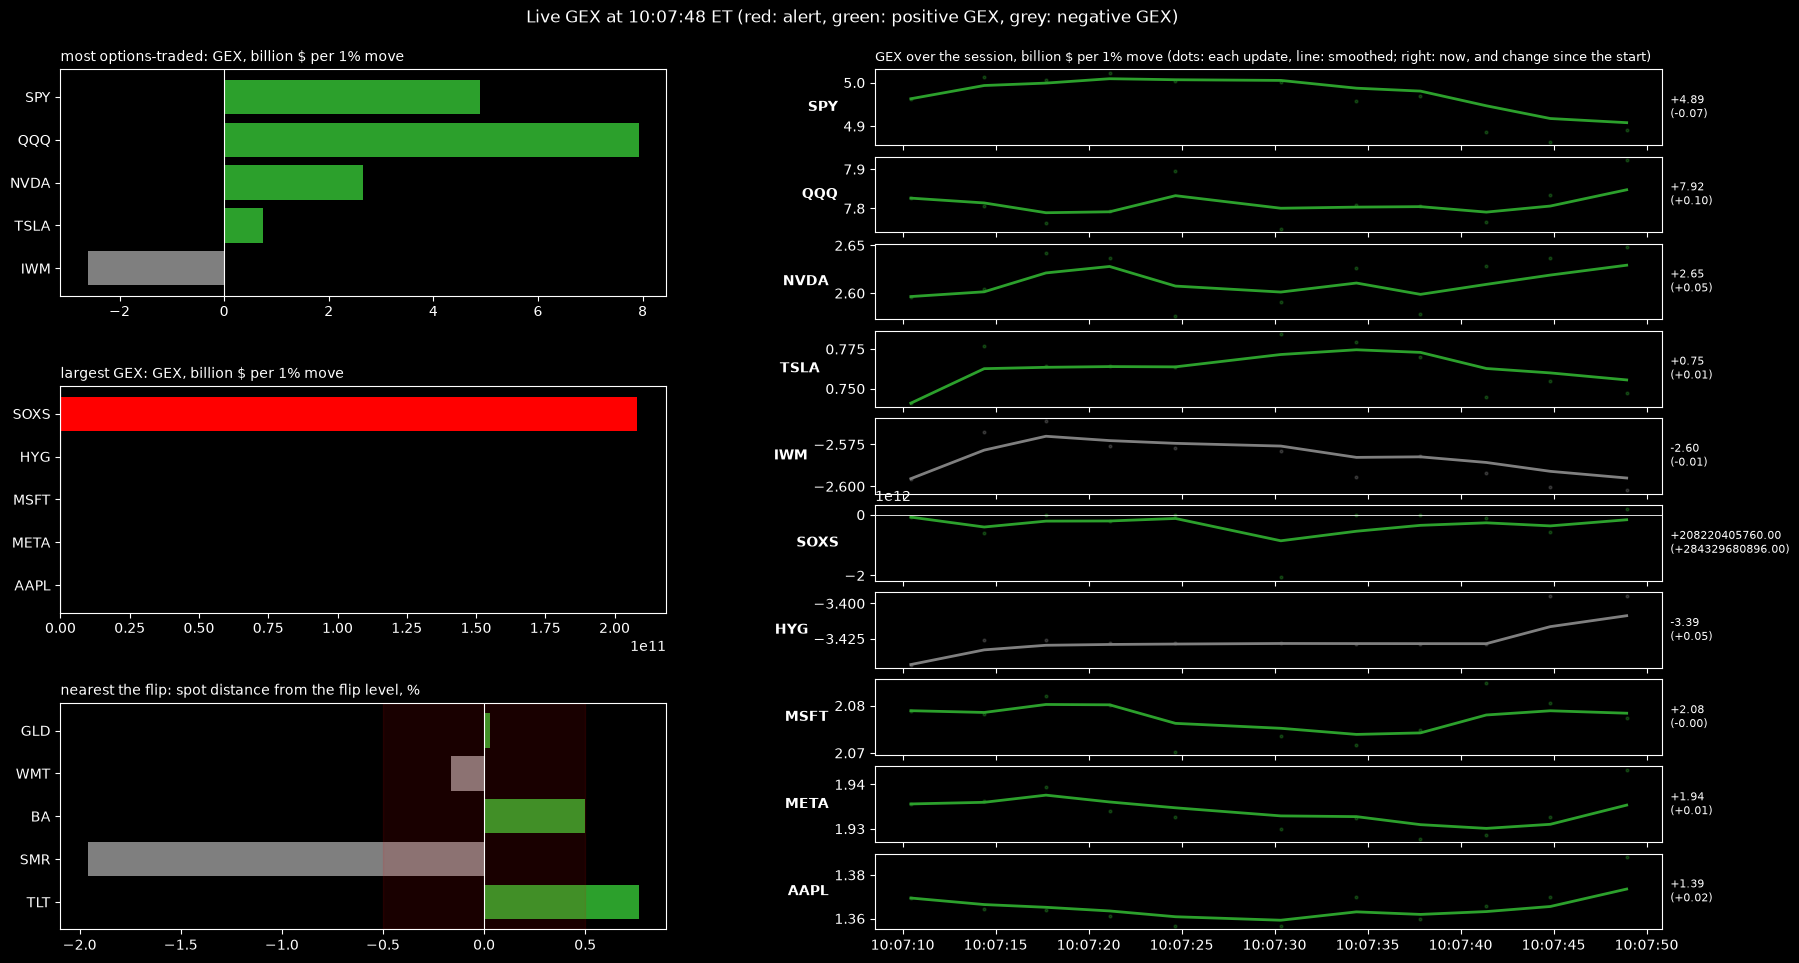

100 tickers, 82,296 options; live data 2.4 s, GPU 0.666 s

ticker,flipped_to,flipped_at,minutes_ago,flips_in_10_minutes
str,str,str,f64,u32
"""SOXS""","""positive""","""10:07:48""",0.0,7
"""WMT""","""negative""","""10:07:30""",0.3,2


ticker,gex_changed_sign,moved_near_flip,iv_jump,spot,gex,flip,distance_to_flip_pct,atm_iv_pct
str,bool,bool,bool,f64,f64,f64,f64,f64
"""ORCL""",false,false,true,143.705002,0.108879,136.885541,4.981871,46.522486
"""EEM""",false,false,true,67.794998,0.022728,67.174951,0.923034,22.87823
"""SOXS""",true,false,false,28.700001,2.0822e11,28.719563,-0.068114,89.220524


/home/will/git/GPU-Quant-Finance/05-GEX-scanning/.venv/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 80 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/home/will/git/GPU-Quant-Finance/05-GEX-scanning/.venv/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 81 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


stopped


In [7]:
big = None                               # rows of each section, set at the first update and then fixed
near = None
history = []
flips = []                               # every GEX sign change today: ticker, time, new sign
before = None
# fixed output slots, updated in place each update (no clearing, so nothing flashes)
bars_view = display(Markdown("waiting for the first update..."), display_id=True)
status_view = display(Markdown(""), display_id=True)
flips_view = display(Markdown(""), display_id=True)
alerts_view = display(Markdown(""), display_id=True)
try:
    while dt.datetime.now(ET).hour * 60 + dt.datetime.now(ET).minute < CLOSE:
        t0 = time.perf_counter()
        x, now = snapshot()
        t1 = time.perf_counter()
        iv, gex_grid = gex_on_gpu(x)
        t2 = time.perf_counter()
        table = live_table(x, iv, gex_grid, now)
        found = alerts(table, before)
        history.append(table)
        before = table

        if big is None:                      # first update: largest GEX, then nearest the flip
            big = table.filter(~pl.col("ticker").is_in(TOP)).sort(pl.col("gex").abs(), descending=True)["ticker"].head(N).to_list()
            near = (table.filter(~pl.col("ticker").is_in(TOP + big), pl.col("distance_to_flip_pct").is_finite())
                    .sort(pl.col("distance_to_flip_pct").abs())["ticker"].head(N).to_list())

        for row in found.filter(pl.col("gex_changed_sign")).iter_rows(named=True):
            flips.append({"ticker": row["ticker"], "time": now, "gex_now": "negative" if row["gex"] < 0 else "positive"})
        recent = [{"ticker": f["ticker"], "flipped_to": f["gex_now"], "flipped_at": f"{f['time']:%H:%M:%S}",
                "minutes_ago": round((now - f["time"]).total_seconds() / 60, 1)}
                for f in flips if now - f["time"] <= FLIP_WINDOW]

        distance = dict(zip(table["ticker"], table["distance_to_flip_pct"]))
        gex = dict(zip(table["ticker"], table["gex"]))
        flagged = set(found["ticker"])

        lanes = TOP + big                    # GEX over the session, one lane per ticker, each on its own scale
        past = pl.concat(history).filter(pl.col("ticker").is_in(lanes)).sort("at")
        fig = plt.figure(figsize=(18, 10))
        grid = fig.add_gridspec(1, 2, width_ratios=[1, 1.3], wspace=0.3)
        left = grid[0].subgridspec(3, 1, hspace=0.4)
        right = grid[1].subgridspec(len(lanes), 1, hspace=0.15)

        axes = [fig.add_subplot(left[i]) for i in range(3)]
        charts = [
            (TOP, gex, "most options-traded: GEX, billion $ per 1% move"),
            (big, gex, "largest GEX: GEX, billion $ per 1% move"),
            (near, distance, "nearest the flip: spot distance from the flip level, %"),
        ]
        for ax, (tickers, values, title) in zip(axes, charts):
            colors = ["red" if t in flagged else ("tab:green" if gex.get(t, 0) > 0 else "tab:gray") for t in tickers]
            ax.barh(tickers, [values.get(t, np.nan) for t in tickers], color=colors)
            ax.invert_yaxis()                # first ticker at the top
            ax.axvline(0, color="white", linewidth=0.8)
            ax.set_title(title, loc="left", fontsize=10)
        axes[2].axvspan(-NEAR_FLIP_PCT, NEAR_FLIP_PCT, color="red", alpha=0.1)

        axes2 = []
        for i, ticker in enumerate(lanes):
            ax = fig.add_subplot(right[i], sharex=axes2[0] if axes2 else None)
            axes2.append(ax)
            one = past.filter(pl.col("ticker") == ticker).with_columns(smooth=pl.col("gex").ewm_mean(alpha=SMOOTH))
            color = "tab:green" if one["gex"][-1] > 0 else "tab:gray"
            ax.scatter(one["at"].to_list(), one["gex"], s=4, color=color, alpha=0.3)
            ax.plot(one["at"].to_list(), one["smooth"], color=color, linewidth=2)
            if one["gex"].min() < 0 < one["gex"].max():
                ax.axhline(0, color="white", linewidth=0.6)   # zero line only when the lane crosses it, so each lane keeps its own scale
            ax.set_ylabel(ticker, rotation=0, ha="right", va="center", fontweight="bold")
            ax.text(1.01, 0.5, f"{one['gex'][-1]:+.2f}\n({one['gex'][-1] - one['gex'][0]:+.2f})", transform=ax.transAxes, va="center", fontsize=8)
            if i < len(lanes) - 1:
                ax.tick_params(labelbottom=False)
        axes2[0].set_title("GEX over the session, billion $ per 1% move (dots: each update, line: smoothed; right: now, and change since the start)", loc="left", fontsize=9)

        fig.suptitle(f"Live GEX at {now:%H:%M:%S} ET (red: alert, green: positive GEX, grey: negative GEX)")
        fig.subplots_adjust(left=0.06, right=0.95, top=0.92, bottom=0.06)
        bars_view.update(fig)
        plt.close(fig)

        status_view.update(Markdown(f"{len(TICKERS)} tickers, {len(x['K']):,} options; live data {t1 - t0:.1f} s, GPU {t2 - t1:.3f} s"))
        if recent:
            flips_view.update(pl.DataFrame(recent).sort("flipped_at", descending=True)
                            .group_by("ticker", maintain_order=True)
                            .agg(pl.col("flipped_to").first(), pl.col("flipped_at").first(), pl.col("minutes_ago").first(), flips_in_10_minutes=pl.len()))
        else:
            flips_view.update(Markdown("No GEX flips in the last 10 minutes"))
        alerts_view.update(found)
except KeyboardInterrupt:
    print("stopped")